# IET SMP Assignment: Variational Autoencoders (VAE) with MNIST

**Total Marks: 20**

**Instructions:**
- Read each question carefully.
- Write the required code and brief explanations in the notebook cells provided.
- Run all code cells after completing the assignment.
- Keep your answers clear, concise, and well-organized.

### Assignment Overview
This notebook is structured as a short practical assignment on Variational Autoencoders using the MNIST dataset. You will define the model, train it, and generate new handwritten digit samples.

### Mark Distribution
- Concept of VAE and latent space: **3 marks**
- Encoder design and reparameterization trick: **5 marks**
- VAE loss function: **4 marks**
- Training setup and loop: **5 marks**
- Generating new digits and interpretation: **3 marks**


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


### Question 1: VAE Concept, Encoder Design, and Reparameterization Trick [8 marks]

Explain the purpose of a Variational Autoencoder and how its latent space differs from that of a standard autoencoder.

Then describe how the VAE encoder produces the latent distribution parameters and why the reparameterization trick is required for backpropagation.

In your answer, include:
- the role of mean ($\mu$)
- the role of log-variance ($\log(\sigma^2)$)
- how $z = \mu + \sigma \odot \epsilon$ supports training


### Answer:
VAE is a generative model designed to learn the underlying distribution of input data. It maps inputs to probability distributions. A standard autoencoder learns a deterministic mapping whereas the VAE learns a probabilistic mapping. The unit space becomes continuous and smooth. 

Instead of mapping an input x to a single vector z, the VAE encoder outputs parameters that define a distribution. 
Mean ($\mu$): This vector represents the "center" of the distribution in latent space for a given input. It determines where the most likely representation of that specific input lies.
Log-variance ($\log(\sigma^2)$): The encoder outputs the log-variance rather than the variance directly to ensure numerical stability and to allow the variance to be any positive value after exponentiation. $\sigma$ represents the "spread" or uncertainty of the latent encoding.

In a standard VAE, we need to sample z from the distribution to pass it to the decoder. However, the sampling operation is stochastic. The reparameterization trick bypasses this by moving the randomnness to an auxiliary variable.

As randomness is now isolated in epsilon, the relationship between z and the encoder output is now deterministic and differentiable.



In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # TODO: flatten the input and pass it through the encoder
        h1 = F.relu(self.fc1(x))
        # TODO: return the latent mean and log-variance
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        # TODO: sample epsilon and apply the reparameterization trick
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std

    def decode(self, z):
        # TODO: map the latent vector back to the image space
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        # TODO: connect encode -> reparameterize -> decode
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


# TODO: instantiate the model after completing the class
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
print("VAE template ready for student implementation")


VAE template ready for student implementation


### Question 2: VAE Loss Function [4 mark]

Write the loss function for the VAE and briefly explain the purpose of each term.

Your response should include:
- reconstruction loss using binary cross entropy
- KL divergence and why it is needed

#### ANSWER

The goal of reconstruction term is to ensure that the decoded output x cap is as similar as possible to the original x

When the input data is normalized between [0,1] , we treat each pixel as a Bernoulli distribution. BCE measures the error between these distributions.

KLD acts as a regulator. It forces the encoder to distribute the latent codes around the center of the latent space (mean 0) with a specific variance(1).



In [3]:
def vae_loss(recon_x, x, mu, logvar):
    # TODO: compute the reconstruction loss
    recon_loss = F.binary_cross_entropy(recon_x,x,reduction = 'sum')
    # TODO: compute the KL divergence term
    kld = -0.5 * torch.sum(1+logvar - mu.pow(2) - logvar.exp())
    # TODO: return the total VAE loss
    return recon_loss + kld
    raise NotImplementedError("Complete the VAE loss function")


### Question 3: Training the VAE on MNIST [5 marks]

Complete the training setup for the MNIST dataset and train the model for the required number of epochs.

Include:
- dataset loading and preprocessing
- optimizer selection
- forward pass, loss calculation, and parameter updates

In [11]:
# Hyperparameters
# TODO: choose appropriate batch size, number of epochs, and learning rate
batch_size = 128
epochs = 15
learning_rate = 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transformation and loading
# TODO: add any preprocessing needed for MNIST
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = VAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)

# TODO: create the optimizer after the model has been defined
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

# Training Loop
# TODO: complete the training loop
model.train()
for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device).view(-1, 784)

        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)

        loss = vae_loss(recon_batch, data, mu, logvar)

        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch {epoch+1}/{epochs} | Average Loss: {train_loss/len(train_loader.dataset):.4f}')
# Hint: move data to device, run the model, compute the loss, backpropagate, and update weights


Epoch 1/15 | Average Loss: 165.0889
Epoch 2/15 | Average Loss: 121.4243
Epoch 3/15 | Average Loss: 114.5817
Epoch 4/15 | Average Loss: 111.5922
Epoch 5/15 | Average Loss: 109.7621
Epoch 6/15 | Average Loss: 108.5765
Epoch 7/15 | Average Loss: 107.7223
Epoch 8/15 | Average Loss: 107.0593
Epoch 9/15 | Average Loss: 106.5695
Epoch 10/15 | Average Loss: 106.1275
Epoch 11/15 | Average Loss: 105.7400
Epoch 12/15 | Average Loss: 105.4489
Epoch 13/15 | Average Loss: 105.1700
Epoch 14/15 | Average Loss: 104.9168
Epoch 15/15 | Average Loss: 104.7081


### Question 4: Generating New Digits [3 mark]

Use the trained decoder to generate new handwritten digits from random latent vectors.

Then briefly comment on the quality of the generated samples and what this suggests about the learned latent space.

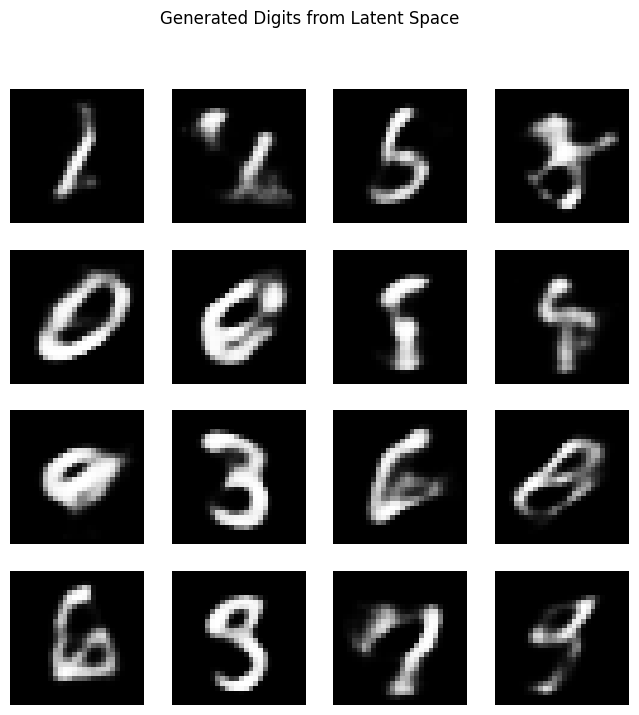

In [14]:
# TODO: write code to sample from the latent space using the trained decoder
# TODO: visualize the generated digits

model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_samples = 16
latent_dim = 20

with torch.no_grad():
    z = torch.randn(num_samples, latent_dim).to(device)

    generated_images = model.decode(z)

    generated_images = generated_images.cpu().view(-1, 28, 28)


fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i], cmap='gray')
    ax.axis('off')
plt.suptitle("Generated Digits from Latent Space")
plt.show()

